# Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [25]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from scipy.stats import skew, fisher_exact
from functions import plot, preprocessing, plot_volcano, format_dataframe, ttest_for_df, batch_correction, categorize_compounds, extract_class, extract_chain_length, extract_dbs_fatty, extract_dbs_sphingo, extract_fatty_hydroxylation, extract_sphingo_hydroxylation, categorize_chain_length
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import networkx as nx

# Variables

In [3]:
data_names = ["wt_1h", "wt_4h", "wt_24h"]
log_trans = True

# Format data

In [4]:
df = format_dataframe("wt_24h", save=False)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h26:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,1.440343,1.202063,0.000000,0.042314,0.000000,0.685638,1.190872,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000000,0.000000,0.000000,0.000000,0.020399,0.023651,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Preprocessing

## Add labeled and unlabeled

In [5]:
for col in [c for c in df.columns[1:] if "_l" not in c]:
    col_l = col + "_l"
    df[f"{"sum_" + col}"] = df[[col, col_l]].sum(axis=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.847428,2.091799,7.087813,6.504548,5.155614,5.702898,13.870321,20.558192,18.960797,13.915158
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.037791,0.019042,0.199781,0.077731,0.081558,0.494038,0.138884,3.530519,0.144430,0.295671
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,7.572767,7.444120,11.740640,11.545599,9.090843,9.388558,43.796729,46.595970,37.556787,33.917899
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.692879,0.760974,17.886067,15.990483,12.473368,12.834583,14.013776,14.818631,16.048410,11.839081
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,1.112527,1.047803,15.199035,13.416505,12.013007,10.146587,16.792512,18.227648,17.536853,14.076387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h26:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,5.814376,7.037880,83.315002,76.042296,75.521128,86.881725,63.386669,69.381603,80.985892,60.190054
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.100365,0.121930,3.175120,2.792694,3.413205,3.687361,2.376625,2.593236,3.722366,2.424922
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Filter not detected compounds

In [6]:
rows_to_drop = []

for i, r in df.filter(regex="sum").iterrows():
    if np.all(r.values == 0):
        rows_to_drop.append(i)

print(rows_to_drop)
df = df.drop(index=rows_to_drop, axis=1)
df    

[78, 92, 96, 100, 104, 110, 170, 176]


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.847428,2.091799,7.087813,6.504548,5.155614,5.702898,13.870321,20.558192,18.960797,13.915158
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.037791,0.019042,0.199781,0.077731,0.081558,0.494038,0.138884,3.530519,0.144430,0.295671
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,7.572767,7.444120,11.740640,11.545599,9.090843,9.388558,43.796729,46.595970,37.556787,33.917899
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.692879,0.760974,17.886067,15.990483,12.473368,12.834583,14.013776,14.818631,16.048410,11.839081
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,1.112527,1.047803,15.199035,13.416505,12.013007,10.146587,16.792512,18.227648,17.536853,14.076387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.141680,0.155408,1.477405,1.646680,1.324467,1.301605,1.369899,1.383700,1.477822,1.185511
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.783860,0.945204,15.583452,15.040617,14.501592,17.340614,13.193404,13.329697,15.536822,12.832825
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,5.814376,7.037880,83.315002,76.042296,75.521128,86.881725,63.386669,69.381603,80.985892,60.190054
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.100365,0.121930,3.175120,2.792694,3.413205,3.687361,2.376625,2.593236,3.722366,2.424922


## Replace zero values
- replace zero values with half minimum value, because log(0) not possible

In [7]:
half_min = np.min([val for val in df.filter(regex=r"^(?!.*compound).*$").values.flatten() if val != 0]) / 2
print("Half minimum:", half_min)

for col in df.columns:
    if col == "compound":
        continue
    
    if "sum" in col:
        #print(col)
        df[col] = df[col].replace(0, half_min)

df

Half minimum: 4.0672700112186134e-05


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.847428,2.091799,7.087813,6.504548,5.155614,5.702898,13.870321,20.558192,18.960797,13.915158
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.037791,0.019042,0.199781,0.077731,0.081558,0.494038,0.138884,3.530519,0.144430,0.295671
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,7.572767,7.444120,11.740640,11.545599,9.090843,9.388558,43.796729,46.595970,37.556787,33.917899
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.692879,0.760974,17.886067,15.990483,12.473368,12.834583,14.013776,14.818631,16.048410,11.839081
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,1.112527,1.047803,15.199035,13.416505,12.013007,10.146587,16.792512,18.227648,17.536853,14.076387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.141680,0.155408,1.477405,1.646680,1.324467,1.301605,1.369899,1.383700,1.477822,1.185511
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.783860,0.945204,15.583452,15.040617,14.501592,17.340614,13.193404,13.329697,15.536822,12.832825
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,5.814376,7.037880,83.315002,76.042296,75.521128,86.881725,63.386669,69.381603,80.985892,60.190054
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.100365,0.121930,3.175120,2.792694,3.413205,3.687361,2.376625,2.593236,3.722366,2.424922


## Relative values

In [8]:
cols = [c for c in df.columns[1:] if "sum" in c]


for exp in ["exp2", "exp4"]:
    for deg in ["22deg", "37deg"]:
        df_exp = df.filter(regex=rf"sum_{exp}_{deg}")
        summe = np.sum(df_exp.values.flatten())

        for col in df_exp.columns:
            df[col] = [val / summe for val in df[col].values]

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.003604,0.004081,0.001590,0.001459,0.001157,0.001279,0.003222,0.004775,0.004404,0.003232
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000074,0.000037,0.000045,0.000017,0.000018,0.000111,0.000032,0.000820,0.000034,0.000069
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.014774,0.014523,0.002634,0.002590,0.002039,0.002106,0.010172,0.010822,0.008723,0.007878
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.001352,0.001485,0.004013,0.003587,0.002798,0.002879,0.003255,0.003442,0.003727,0.002750
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.002170,0.002044,0.003410,0.003010,0.002695,0.002276,0.003900,0.004234,0.004073,0.003269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.000276,0.000303,0.000331,0.000369,0.000297,0.000292,0.000318,0.000321,0.000343,0.000275
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.001529,0.001844,0.003496,0.003374,0.003253,0.003890,0.003064,0.003096,0.003609,0.002981
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.011343,0.013730,0.018691,0.017060,0.016943,0.019491,0.014722,0.016115,0.018810,0.013980
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000196,0.000238,0.000712,0.000627,0.000766,0.000827,0.000552,0.000602,0.000865,0.000563


In [9]:
df.filter(regex="sum_exp4.*37deg").to_numpy().sum()

np.float64(1.0)

## log Transformation

In [10]:
if log_trans == True:
    rel_cols = [c for c in df.columns if "sum" in c]
    print(rel_cols)

    for col in rel_cols:
        df[col] = np.log(df[col].values)

df

['sum_exp2_22deg_1', 'sum_exp2_22deg_2', 'sum_exp2_22deg_3', 'sum_exp2_22deg_4', 'sum_exp2_37deg_1', 'sum_exp2_37deg_2', 'sum_exp2_37deg_3', 'sum_exp2_37deg_4', 'sum_exp4_22deg_1', 'sum_exp4_22deg_2', 'sum_exp4_22deg_3', 'sum_exp4_22deg_4', 'sum_exp4_37deg_1', 'sum_exp4_37deg_2', 'sum_exp4_37deg_3', 'sum_exp4_37deg_4']


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-5.625677,-5.501447,-6.443959,-6.529835,-6.762250,-6.661362,-5.737900,-5.344391,-5.425277,-5.734672
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-9.515163,-10.200600,-10.012870,-10.956842,-10.908775,-9.107479,-10.341765,-7.106206,-10.302609,-9.586158
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-4.214913,-4.232047,-5.939280,-5.956032,-6.195069,-6.162845,-4.588092,-4.526137,-4.741797,-4.843708
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-6.606371,-6.512628,-5.518314,-5.630343,-5.878741,-5.850193,-5.727610,-5.671766,-5.592041,-5.896245
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-6.132837,-6.192775,-5.681104,-5.805851,-5.916346,-6.085199,-5.546718,-5.464711,-5.503346,-5.723152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,-8.193656,-8.101173,-8.012050,-7.903575,-8.121326,-8.138738,-8.052914,-8.042890,-7.977082,-8.197477
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,-6.482996,-6.295826,-5.656127,-5.691582,-5.728078,-5.549285,-5.787934,-5.777657,-5.624438,-5.815645
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-4.479138,-4.288164,-3.979708,-4.071047,-4.077924,-3.937789,-4.218397,-4.128029,-3.973376,-4.270144
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-8.538412,-8.343783,-7.246991,-7.375330,-7.174685,-7.097425,-7.501970,-7.414744,-7.053291,-7.481852


## Statistics

### Mean and Std

In [11]:
# means per experiment and condition
groups = ["sum_exp2_22deg", "sum_exp2_37deg", "sum_exp4_22deg", "sum_exp4_37deg"]

for g in groups:
    df[f"mean_{g}"] = df.filter(regex=g).mean(axis=1)
    df[f"sd_{g}"] = df.filter(regex=g).std(axis=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp4_37deg_3,sum_exp4_37deg_4,mean_sum_exp2_22deg,sd_sum_exp2_22deg,mean_sum_exp2_37deg,sd_sum_exp2_37deg,mean_sum_exp4_22deg,sd_sum_exp4_22deg,mean_sum_exp4_37deg,sd_sum_exp4_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-5.425277,-5.734672,-6.362647,0.084257,-5.550309,0.059035,-6.599352,0.121820,-5.560560,0.178041
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-10.302609,-9.586158,-14.836869,2.903952,-9.757173,0.301133,-10.246492,0.757487,-9.334184,1.321026
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-4.741797,-4.843708,-5.946940,0.208879,-4.295000,0.071904,-6.063306,0.116361,-4.674933,0.125137
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-5.592041,-5.896245,-5.596816,0.088864,-6.608853,0.066664,-5.719398,0.150717,-5.721916,0.111586
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-5.503346,-5.723152,-6.130192,0.235836,-6.243511,0.084530,-5.872125,0.148524,-5.559482,0.098848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,-7.977082,-8.197477,-8.422332,0.146130,-8.219605,0.094839,-8.043922,0.094465,-8.067591,0.080449
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,-5.624438,-5.815645,-6.670297,0.059217,-6.382789,0.067947,-5.656268,0.066800,-5.751418,0.074617
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-3.973376,-4.270144,-4.607416,0.067550,-4.404221,0.071068,-4.016617,0.059786,-4.147487,0.112657
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-7.053291,-7.481852,-8.689808,0.131342,-8.397058,0.087121,-7.223608,0.102325,-7.362964,0.181683


### T-test

In [12]:
df = ttest_for_df(df, df.filter(regex=r"^sum_exp2_22deg").columns, df.filter(regex=r"^sum_exp2_37deg").columns, "exp2")
df = ttest_for_df(df, df.filter(regex=r"^sum_exp4_22deg").columns, df.filter(regex=r"^sum_exp4_37deg").columns, "exp4")

df = ttest_for_df(df, df.filter(regex=r"^sum_exp2_22deg").columns, df.filter(regex=r"^sum_exp4_22deg").columns, "22deg")
df = ttest_for_df(df, df.filter(regex=r"^sum_exp2_37deg").columns, df.filter(regex=r"^sum_exp4_37deg").columns, "37deg")

df

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_exp2,t_stat_exp4,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.000410,-8.340296,0.000303,0.004410,2.767923,0.036798,0.055197,0.094664,0.929545,0.929545
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.091772,-1.037674,0.349033,0.452026,-2.649266,0.067408,0.093334,-0.540726,0.622978,0.641035
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.003610,-14.072814,0.000008,0.000331,0.842955,0.440043,0.465928,4.559607,0.006740,0.011394
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000290,0.023255,0.982263,0.993146,1.213494,0.280590,0.325846,-11.818669,0.000087,0.000740
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.500054,-3.035219,0.027347,0.063543,-1.603776,0.169020,0.206262,-9.109290,0.000113,0.000740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.136326,0.330392,0.752611,0.825782,-3.766718,0.012441,0.024589,-2.117149,0.079818,0.101198
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.009698,1.645587,0.151551,0.225897,-19.674751,0.000001,0.000046,-10.836184,0.000039,0.000645
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.031715,1.777302,0.141216,0.218746,-11.343861,0.000031,0.000320,-3.338421,0.020212,0.029906
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.044387,1.157570,0.302138,0.404558,-15.252782,0.000008,0.000118,-8.889219,0.000624,0.001978


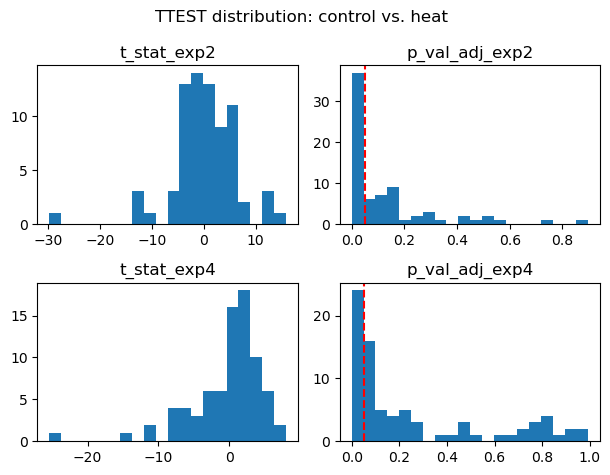

In [13]:
fig, axs = plot(2, 2, "TTEST distribution: control vs. heat", df, [["t_stat_exp2", "p_val_adj_exp2"], ["t_stat_exp4", "p_val_adj_exp4"]], 20)
axs[0, 1].axvline(0.05, linestyle="--", color="red")
axs[1, 1].axvline(0.05, linestyle="--", color="red")

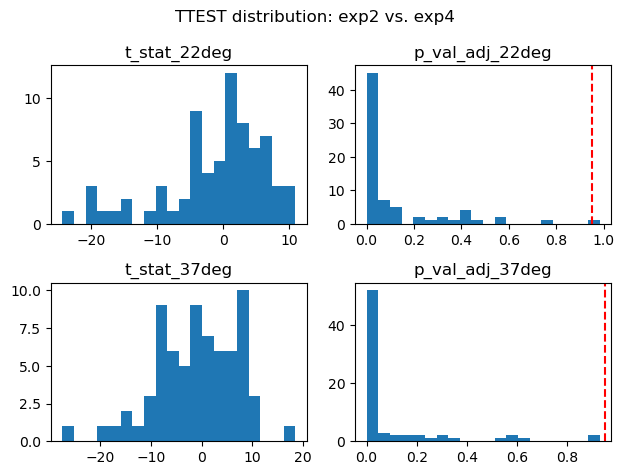

In [14]:
fig, axs = plot(2, 2, "TTEST distribution: exp2 vs. exp4", df, [["t_stat_22deg", "p_val_adj_22deg"], ["t_stat_37deg", "p_val_adj_37deg"]], 20)
axs[0, 1].axvline(0.95, linestyle="--", color="red")
axs[1, 1].axvline(0.95, linestyle="--", color="red")

-> no significant differences expected between exp2 and exp4

### Fold change

In [15]:
## fold change between 22deg and 37deg
df["log2_fc_exp2"] = df["mean_sum_exp2_37deg"] - df["mean_sum_exp2_22deg"] # -> FC = 1 means under heat stress compound is twice as high 
df["log2_fc_exp4"] = df["mean_sum_exp4_37deg"] - df["mean_sum_exp4_22deg"]
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.000303,0.004410,2.767923,0.036798,0.055197,0.094664,0.929545,0.929545,0.812339,1.038791
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.349033,0.452026,-2.649266,0.067408,0.093334,-0.540726,0.622978,0.641035,5.079696,0.912307
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.000008,0.000331,0.842955,0.440043,0.465928,4.559607,0.006740,0.011394,1.651939,1.388373
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.982263,0.993146,1.213494,0.280590,0.325846,-11.818669,0.000087,0.000740,-1.012037,-0.002518
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.027347,0.063543,-1.603776,0.169020,0.206262,-9.109290,0.000113,0.000740,-0.113320,0.312643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.752611,0.825782,-3.766718,0.012441,0.024589,-2.117149,0.079818,0.101198,0.202727,-0.023668
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.151551,0.225897,-19.674751,0.000001,0.000046,-10.836184,0.000039,0.000645,0.287508,-0.095150
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.141216,0.218746,-11.343861,0.000031,0.000320,-3.338421,0.020212,0.029906,0.203195,-0.130870
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.302138,0.404558,-15.252782,0.000008,0.000118,-8.889219,0.000624,0.001978,0.292750,-0.139357


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


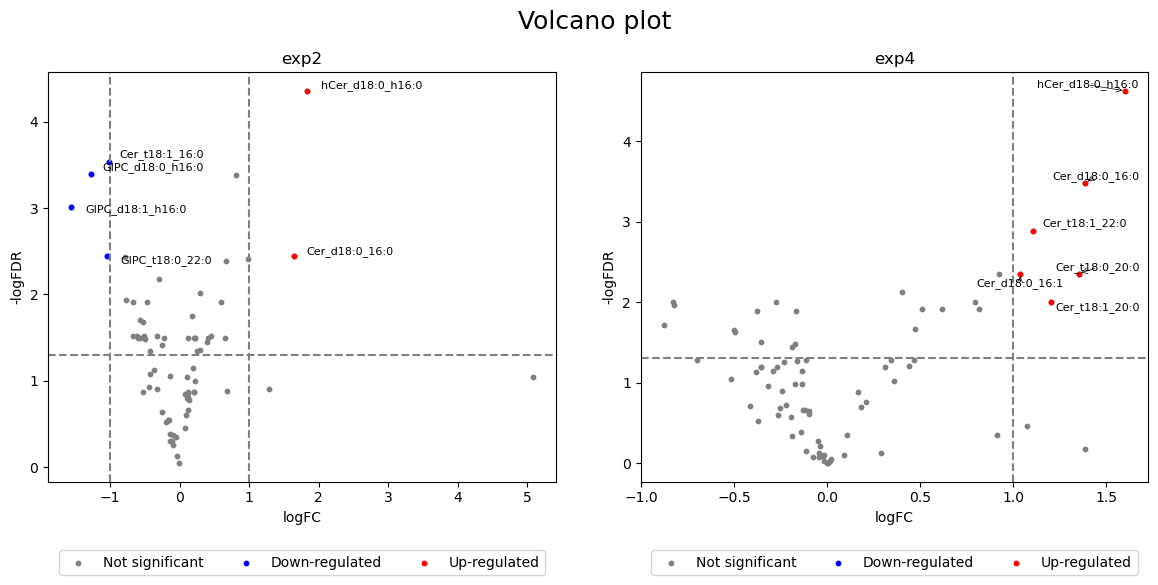

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))

for i, exp in enumerate(["exp2", "exp4"]):
    df_volcano = df[["compound", f"log2_fc_{exp}", f"p_val_adj_{exp}"]]
    df_volcano.columns = ["compounds", "log2_fc", "p_val_adj"]

    plot_volcano(df_volcano, compounds_col="compounds", fcr_col="p_val_adj", fc_col="log2_fc", significance=0.05, fc_level=1, title=exp, ax=axs[i])

plt.suptitle("Volcano plot", fontsize=18)
plt.tight_layout()
plt.show()

### Skewness

In [17]:
df["skew_exp2_22deg"] = [skew(df.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp2_37deg"] = [skew(df.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp4_22deg"] = [skew(df.filter(regex=r".*sum_exp4_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp4_37deg"] = [skew(df.filter(regex=r".*sum_exp4_37deg_\d+$").values[i]) for i in range(len(df))]
df

C:\Users\janni\AppData\Local\Temp\ipykernel_27432\1238662511.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp2_22deg"] = [skew(df.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_27432\1238662511.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp2_37deg"] = [skew(df.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_27432\1238662511.py:3: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp4_22deg"] = [skew(df.filter(regex=r".*sum_exp4_22deg

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4,skew_exp2_22deg,skew_exp2_37deg,skew_exp4_22deg,skew_exp4_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.055197,0.094664,0.929545,0.929545,0.812339,1.038791,-1.152613,-0.106051,-0.065406,0.076271
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.093334,-0.540726,0.622978,0.641035,5.079696,0.912307,1.154701,-0.408453,0.484035,0.988173
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.465928,4.559607,0.006740,0.011394,1.651939,1.388373,0.496364,0.010612,-0.020859,-0.147625
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.325846,-11.818669,0.000087,0.000740,-1.012037,-0.002518,0.545281,0.094276,0.186472,-0.536461
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.206262,-9.109290,0.000113,0.000740,-0.113320,0.312643,0.702666,0.106714,-0.190678,-0.868226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.079917,0.123979,0.071787,0.101520,0.115765,0.090060,0.108813,0.120946,1.260527,...,0.024589,-2.117149,0.079818,0.101198,0.202727,-0.023668,0.030198,-0.417549,0.439124,-0.687384
168,GIPC_t18:1_h26:1,0.692600,0.806377,0.780352,0.785927,0.889579,0.855230,0.783860,0.945204,14.540251,...,0.000046,-10.836184,0.000039,0.000645,0.287508,-0.095150,-1.016511,-0.265049,0.679441,1.032467
172,GIPC_t18:1_h26:0,5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000320,-3.338421,0.020212,0.029906,0.203195,-0.130870,-0.930465,0.771972,0.173642,0.539157
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000118,-8.889219,0.000624,0.001978,0.292750,-0.139357,-0.830446,-0.763138,-0.321824,1.050152


(<Figure size 640x480 with 4 Axes>,
 array([[<Axes: title={'center': 'skew_exp2_22deg'}>,
         <Axes: title={'center': 'skew_exp2_37deg'}>],
        [<Axes: title={'center': 'skew_exp4_22deg'}>,
         <Axes: title={'center': 'skew_exp4_37deg'}>]], dtype=object))

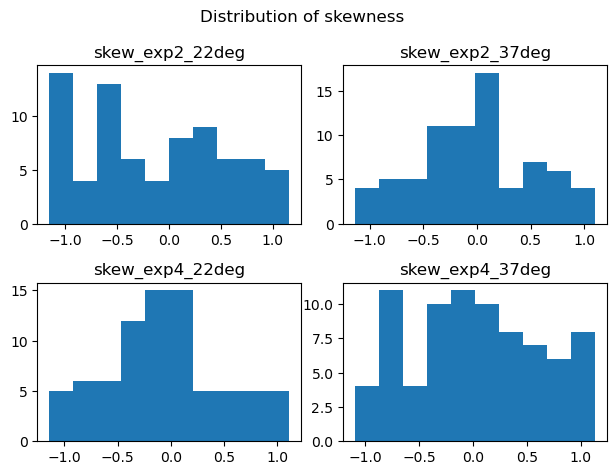

In [18]:
plot(2, 2, "Distribution of skewness", df, [["skew_exp2_22deg", "skew_exp2_37deg"], ["skew_exp4_22deg", "skew_exp4_37deg"]], 10)

## Save results
for every component:
- expX_Xdeg_X -> raw absolute values
- expX_Xdeg_X_l -> raw absolute values labeled
- sum_expX_Xdeg_X -> sum of absolute unlabeled + labeled, relative values, log transformation
- mean_sum_expX_Xdeg -> mean of sum_expX_Xdeg_1-4
- sd_sum_expX_Xdeg -> standard deviation of sum_expX_Xdeg_1-4
- t_stat_expX, p_val_expX, p_val_adj_expX -> t_value, p_value and Benjamin-Hochberg adjusted p_value of control vs. heat
- t_stat_Xdeg, p_val_Xdeg, p_val_adj_Xdeg -> t_value, p_value and Benjamin-Hochberg adjusted p_value of exp2 vs. exp4
- log2_fc_expX -> log2 difference between control and heat
- skew_expX_Xdeg -> skewness of sum_expX_Xdeg_1-4 values

In [19]:
df.to_csv(f"../data/preprocessed/{data_name}.csv", index=False)

NameError: name 'data_name' is not defined

# Principle component analysis

## Centering and scaling
- x scaled = (x - mean(x)) / std(x)

In [20]:
df_pca = df.filter(regex=r"^sum_exp\d+_\d+deg_\d+").T
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca)

df_pca_scaled

array([[-0.60291842, -1.98267304, -0.47884615, ..., -1.7599867 ,
        -1.52162478, -1.2125744 ],
       [-0.61121862, -1.98267304, -0.90249437, ..., -1.09872134,
        -1.06453886, -1.08706538],
       [-1.01046268, -1.98267304, -1.21571706, ..., -1.2577734 ,
        -0.99509911, -1.20318718],
       ...,
       [ 1.38862181,  1.42724434,  0.91526463, ...,  0.68496324,
         0.77622944,  0.95990943],
       [ 1.22193178,  0.26862101,  0.64070114, ...,  1.32346862,
         1.33334222,  1.42467646],
       [ 0.58432995,  0.52831828,  0.5109547 , ...,  0.09822507,
         0.67279568,  0.72099955]], shape=(16, 82))

## PCA

In [21]:
pca = PCA(n_components=2)
scores = pca.fit_transform(df_pca_scaled)
scores

array([[ 8.47339753, -3.74419606],
       [ 8.51646847, -4.05768313],
       [ 8.40221999, -3.80940557],
       [ 6.16124799, -3.11418203],
       [ 5.69829169,  5.08222046],
       [ 6.2800306 ,  5.01470335],
       [ 5.75084338,  4.43450694],
       [ 5.06164256,  4.32766152],
       [-6.10407576, -4.35706418],
       [-6.43058911, -3.90340805],
       [-5.15163084, -3.43019672],
       [-6.91302297, -4.37507217],
       [-6.81007142,  2.33679214],
       [-8.08117885,  3.57505671],
       [-8.18786911,  3.32501791],
       [-6.66570414,  2.69524887]])

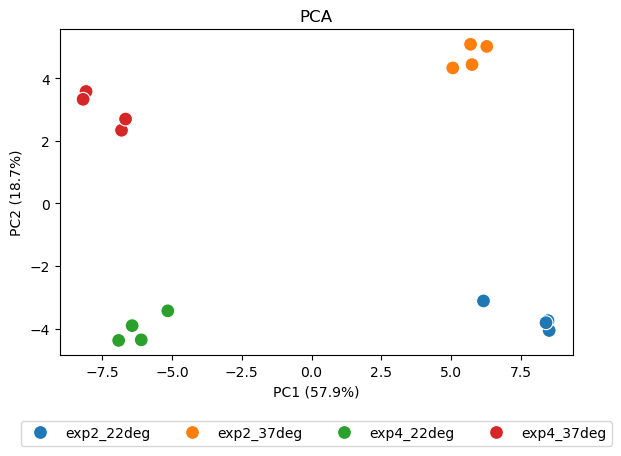

In [22]:
# PCA scores in DataFrame
df_pca_plot = pd.DataFrame(scores, columns=['PC1', 'PC2'])

# add groups
groups = ["exp2_22deg"]*4 + ["exp2_37deg"]*4 + ["exp4_22deg"]*4 + ["exp4_37deg"]*4
df_pca_plot['group'] = groups

# Plot
sns.scatterplot(data=df_pca_plot, x="PC1", y="PC2", hue="group", s=100)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA")
plt.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.3))
plt.tight_layout()

# Batch correction
## Linear model
y = µ + ß1 * condition + ß2 * batch + e  

Where:

y = measured intensity of the metabolite (log-transformed)  
μ = intercept (mean of the reference group)  
β1= effect of the experimental condition (e.g., temperature)  
β2 = batch effect (e.g., experiment 2 vs 4)  
e = residual error (assumed normally distributed, mean 0)


In [4]:
batch_df = preprocessing(pd.read_csv("../data/formated/wt_24h.csv"), replace_zero="half_min_loc", relative_values=False)
results_df = batch_correction(batch_df)
results_df

c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:141: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[i, sum_cols] = df.loc[i, sum_cols].replace(0, half_min)
c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:141: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[i, sum_cols] = df.loc[i, sum_cols].replace(0, half_min)
c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:141: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old beha

,compound,EffectSize_condition,p_val_condition,p_val_batch,R2,p_val_adj_condition
0,Cer_d18:0_16:1,0.826202,1.803236e-07,4.983508e-12,0.980425,2.957307e-06
1,Cer_d18:1_16:0,0.850759,8.482787e-02,9.620912e-05,0.724108,1.264706e-01
2,Cer_d18:0_16:0,1.420793,1.604046e-10,7.278261e-12,0.984712,6.576590e-09
3,Cer_t18:1_16:0,-0.606641,3.311330e-03,2.164133e-09,0.944687,9.697466e-03
4,Cer_t18:0_16:0,0.000298,9.979675e-01,1.102144e-11,0.973969,9.979675e-01
...,...,...,...,...,...,...
77,GIPC_t18:0_h25:0,-0.009834,8.740469e-01,9.433588e-15,0.991209,9.263576e-01
78,GIPC_t18:1_h26:1,-0.003185,9.514306e-01,6.490143e-17,0.995912,9.631766e-01
79,GIPC_t18:1_h26:0,-0.063201,2.533929e-01,6.615002e-16,0.994161,3.196649e-01
80,GIPC_t18:1_h28:1,-0.022667,7.909694e-01,6.192561e-15,0.991760,8.764796e-01


- Effect size condition: 1 = 2-fold upregulated in 37deg compared to 22deg
- p-value condition: significant temperature-regulated metabolites  
- p-value batch: significant batch effect  
- R2: high values mean clear differentiation between groups, low spread within groups, consistent replicates

## Categorize compounds

In [5]:
results_df["category"] = categorize_compounds(results_df)
print(f"{len(results_df[results_df["category"] == "both"])} compounds show both significant temperature and batch effect,")
print(f"{len(results_df[results_df["category"] == "condition"])} compounds show significant temperature effect,")
print(f"{len(results_df[results_df["category"] == "batch"])} compounds show significant batch effect,")
print(f"{len(results_df[results_df["category"] == "neutral"])} compounds show no significant effect.")
results_df

18 compounds show both significant temperature and batch effect,
0 compounds show significant temperature effect,
64 compounds show significant batch effect,
0 compounds show no significant effect.


,compound,EffectSize_condition,p_val_condition,p_val_batch,R2,p_val_adj_condition,category
0,Cer_d18:0_16:1,0.826202,1.803236e-07,4.983508e-12,0.980425,2.957307e-06,both
1,Cer_d18:1_16:0,0.850759,8.482787e-02,9.620912e-05,0.724108,1.264706e-01,batch
2,Cer_d18:0_16:0,1.420793,1.604046e-10,7.278261e-12,0.984712,6.576590e-09,both
3,Cer_t18:1_16:0,-0.606641,3.311330e-03,2.164133e-09,0.944687,9.697466e-03,both
4,Cer_t18:0_16:0,0.000298,9.979675e-01,1.102144e-11,0.973969,9.979675e-01,batch
...,...,...,...,...,...,...,...
77,GIPC_t18:0_h25:0,-0.009834,8.740469e-01,9.433588e-15,0.991209,9.263576e-01,batch
78,GIPC_t18:1_h26:1,-0.003185,9.514306e-01,6.490143e-17,0.995912,9.631766e-01,batch
79,GIPC_t18:1_h26:0,-0.063201,2.533929e-01,6.615002e-16,0.994161,3.196649e-01,batch
80,GIPC_t18:1_h28:1,-0.022667,7.909694e-01,6.192561e-15,0.991760,8.764796e-01,batch


## Volcano plot

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


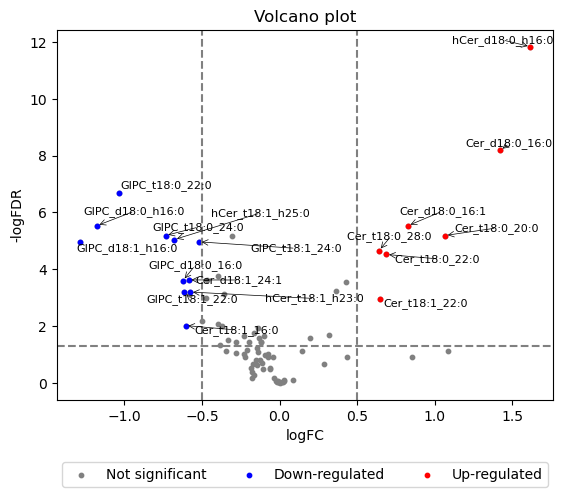

In [6]:
fig, ax = plot_volcano(results_df, compounds_col="compound", fcr_col="p_val_adj_condition", fc_col="EffectSize_condition", title="Volcano plot", significance=0.05, fc_level=0.5)

# Enrichment Analysis

## Add features

In [27]:
## Significance
results_df["significant"] = results_df["p_val_adj_condition"] < 0.05
results_df["class"] = results_df["compound"].apply(extract_class)
results_df["chain_length"] = results_df["compound"].apply(extract_chain_length)
results_df["chain_category"] = results_df["chain_length"].apply(categorize_chain_length)
results_df["sphingo_hydroxylation"] = results_df["compound"].apply(extract_sphingo_hydroxylation)
results_df["fatty_hydroxylation"] = results_df["compound"].apply(extract_fatty_hydroxylation)
results_df["dbs_fatty"] = results_df["compound"].apply(extract_dbs_fatty)
results_df["dbs_sphingo"] = results_df["compound"].apply(extract_dbs_sphingo)
results_df

,compound,EffectSize_condition,p_val_condition,p_val_batch,R2,p_val_adj_condition,category,significant,class,chain_length,chain_category,sphingo_hydroxylation,fatty_hydroxylation,double_bounds,dbs_fatty,dbs_sphingo
0,Cer_d18:0_16:1,0.826202,1.803236e-07,4.983508e-12,0.980425,2.957307e-06,both,True,Ceramide,16,short,2,False,1,1,0
1,Cer_d18:1_16:0,0.850759,8.482787e-02,9.620912e-05,0.724108,1.264706e-01,batch,False,Ceramide,16,short,2,False,0,0,1
2,Cer_d18:0_16:0,1.420793,1.604046e-10,7.278261e-12,0.984712,6.576590e-09,both,True,Ceramide,16,short,2,False,0,0,0
3,Cer_t18:1_16:0,-0.606641,3.311330e-03,2.164133e-09,0.944687,9.697466e-03,both,True,Ceramide,16,short,3,False,0,0,1
4,Cer_t18:0_16:0,0.000298,9.979675e-01,1.102144e-11,0.973969,9.979675e-01,batch,False,Ceramide,16,short,3,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,GIPC_t18:0_h25:0,-0.009834,8.740469e-01,9.433588e-15,0.991209,9.263576e-01,batch,False,GIPC,25,very_long,3,True,0,0,0
78,GIPC_t18:1_h26:1,-0.003185,9.514306e-01,6.490143e-17,0.995912,9.631766e-01,batch,False,GIPC,26,very_long,3,True,1,1,1
79,GIPC_t18:1_h26:0,-0.063201,2.533929e-01,6.615002e-16,0.994161,3.196649e-01,batch,False,GIPC,26,very_long,3,True,0,0,1
80,GIPC_t18:1_h28:1,-0.022667,7.909694e-01,6.192561e-15,0.991760,8.764796e-01,batch,False,GIPC,28,very_long,3,True,1,1,1


In [14]:
results_df.to_csv("test.csv", index=False)

## Overrepresentation analysis

In [15]:
def overrepresentation_analysis(df, ora_col):
    total = len(df)
    sig_total = df["significant"].sum()
    ora_results = []

    for cls in df[ora_col].unique():
        mask = df[ora_col] == cls

        class_total = mask.sum()
        class_sig = df[mask]["significant"].sum()

        a = class_sig
        b = class_total - class_sig
        c = sig_total - class_sig
        d = total - class_total - c
        
        table = [[a, b], [c, d]]
        oddsratio, pvalue = fisher_exact(table, alternative="greater")
        ora_results.append([cls, class_total, class_sig, oddsratio, pvalue])

    ora_df = pd.DataFrame(ora_results, columns=[ora_col, "n_total", "n_significant", "odds_ratio", "p_value"])
    ora_df["p_adj"] = multipletests(ora_df["p_value"], method="fdr_bh")[1]
    return ora_df

ora_class = overrepresentation_analysis(results_df, "class")
ora_class

,class,n_total,n_significant,odds_ratio,p_value,p_adj
0,Ceramide,21,11,1.136667,0.500000,0.666667
1,Hydroxy_ceramide,23,12,1.128527,0.500000,0.666667
2,Glycosyl_ceramide,6,5,5.555556,0.100587,0.402348
3,GIPC,32,13,0.537594,0.943799,0.943799


In [16]:
ora_chain_length = overrepresentation_analysis(results_df, "chain_category")
ora_chain_length

,chain_category,n_total,n_significant,odds_ratio,p_value,p_adj
0,short,18,11,1.780952,0.212059,0.424118
1,very_long,64,30,0.561497,0.909330,0.909330


In [17]:
ora_sphingo_hydr = overrepresentation_analysis(results_df, "sphingo_hydroxylation")
ora_sphingo_hydr

,sphingo_hydroxylation,n_total,n_significant,odds_ratio,p_value,p_adj
0,2,14,8,1.414141,0.385058,0.770117
1,3,68,33,0.707143,0.810342,0.810342


In [18]:
ora_fatty_hydr = overrepresentation_analysis(results_df, "fatty_hydroxylation")
ora_fatty_hydr

,fatty_hydroxylation,n_total,n_significant,odds_ratio,p_value,p_adj
0,False,32,19,1.860140,0.128777,0.257554
1,True,50,22,0.537594,0.943799,0.943799


In [19]:
ora_dbs = overrepresentation_analysis(results_df, "double_bounds")
ora_dbs

,double_bounds,n_total,n_significant,odds_ratio,p_value,p_adj
0,1,19,8,0.661157,0.852429,0.852429
1,0,63,33,1.512500,0.300729,0.601459


## PCA with significant compounds

In [20]:
sig_metabolites = results_df.loc[results_df["p_val_adj_condition"] < 0.05, "compound"].tolist()
X = batch_df_t[sig_metabolites]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

NameError: name 'batch_df_t' is not defined

Text(0.5, 1.0, 'PCA – significant metabolites only')

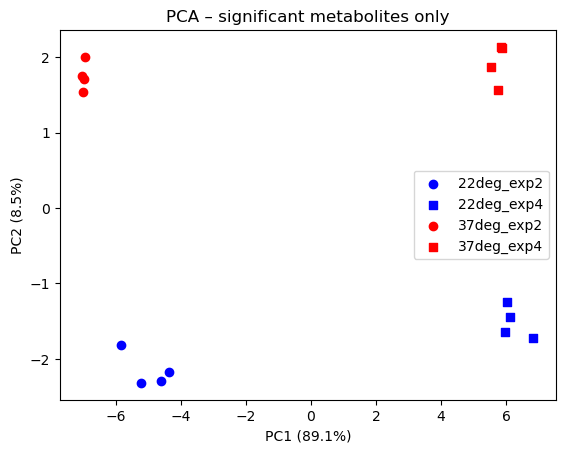

In [ ]:
meta = pd.DataFrame(index=batch_df_t.index)
meta["batch"] = [meta.index[i].split("_")[1] for i in range(len(meta))]
meta["condition"] = [meta.index[i].split("_")[2] for i in range(len(meta))]

colors = {"22deg": "blue", "37deg": "red"}
markers = {"exp2": "o", "exp4": "s"}

for cond in meta["condition"].unique():
    for batch in meta["batch"].unique():
        
        idx = (meta["condition"] == cond) & (meta["batch"] == batch)
        
        plt.scatter(
            X_pca[idx,0],
            X_pca[idx,1],
            color=colors[cond],
            marker=markers[batch],
            label=f"{cond}_{batch}"
        )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()
plt.title("PCA – significant metabolites only")

# Mutant Analysis (sld 24h)

## Format data

In [16]:
df_sld_form = format_dataframe("sld_24h", save=True)
df_sld_form

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955687,3.749633,3.815411,3.620979,13.400314,...,3.167761,3.422592,5.725892,5.958604,5.244753,5.270445,32.887509,44.181303,35.490193,41.497261
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668387,...,0.601956,0.622684,10.840034,11.408771,12.210812,10.112965,12.145008,12.006661,12.810125,14.414790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.000000,0.000000,1.045956,0.948697,1.653506,1.267221,0.865090,0.523967,0.527134,0.880719
172,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
174,GIPC_t18:1_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.070369,0.066726,0.082485,0.079501,0.094786,0.074484,0.087776,0.093676,3.488376,...,0.005815,0.000000,0.069398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
df_sld_form["compound"].values

array(['Cer_d18:0_16:1', 'Cer_d18:1_16:0', 'Cer_d18:0_16:0',
       'Cer_t18:1_16:0', 'Cer_t18:0_16:0', 'Cer_d18:1_18:0',
       'Cer_t18:1_20:0', 'Cer_t18:0_20:0', 'Cer_t18:1_22:0',
       'Cer_t18:0_22:0 ', 'Cer_d18:1_24:1', 'Cer_t18:1_24:1 ',
       'Cer_t18:0_24:1 ', 'Cer_t18:1_24:0 ', 'Cer_t18:0_24:0 ',
       'Cer_t18:1_26:1 ', 'Cer_t18:0_26:1 ', 'Cer_t18:1_26:0 ',
       'Cer_t18:0_28:1', 'Cer_t18:1_28:0 ', 'Cer_t18:0_28:0 ',
       'hCer_d18:1_h16:0', 'hCer_d18:0_h16:0', 'hCer_t18:1_h16:0',
       'hCer_t18:0_h16:0', 'hCer_t18:1_h20:0 ', 'hCer_t18:1_h22:0',
       'hCer_t18:0_h22:0', 'hCer_d18:1_h24:0', 'hCer_t18:1_h23:0',
       'hCer_t18:0_h23:0', 'hCer_t18:1_h24:1', 'hCer_t18:0_h24:1',
       'hCer_t18:1_h24:0', 'hCer_t18:0_h24:0', 'hCer_t18:0_h25:1',
       'hCer_t18:1_h25:0', 'hCer_t18:0_h25:0', 'hCer_t18:1_h26:1 ',
       'hCer_t18:0_h26:1', 'hCer_t18:1_h26:0', 'hCer_t18:0_h26:0',
       'hCer_t18:1_h27:0', 'hCer_t18:1_h28:0', 'hCer_t18:0_h28:0',
       'GlcCer_t18:1_h16:

## Preprocessing

In [5]:
df_sld_pre = preprocessing(df_sld_form, add_unlabeled_labeled=True, replace_zero="half_min_glob", relative_values=True, log_transformation=True)
df_sld_pre

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-13.246105,-13.246105,-15.456017,-9.507844,-9.241808,-9.228136,-8.852873,-9.459796,-9.555136,-10.195848
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,-13.246105,-8.382054,-7.566432,-9.651119,-10.596226,-8.762282,-9.663568,-8.683709,-7.614856,-6.941203
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,-4.183961,-4.175349,-5.386318,-5.395759,-5.502858,-5.447871,-4.344145,-4.070097,-4.307181,-4.163677
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,-10.847692,-11.146374,-9.660496,-9.288466,-9.407352,-9.309687,-10.275961,-9.893725,-9.985078,-10.245279
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,-5.637915,-5.708397,-4.739834,-4.728142,-4.665382,-4.777555,-5.171993,-5.138360,-5.130196,-5.025517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,-6.548240,-6.658398,-5.775277,-5.753664,-5.934747,-5.794083,-6.150036,-6.167374,-6.104178,-6.106703
168,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,-8.721090,-8.571367,-8.351275,-8.432058,-8.318586,-8.413565,-8.446535,-8.646156,-8.478963,-8.604240
170,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,-5.399469,-5.438954,-5.308641,-5.330574,-5.327023,-5.301400,-5.424671,-5.380228,-5.256626,-5.339077
172,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,-6.272644,-6.308474,-6.228574,-6.415655,-6.374415,-6.377162,-6.684162,-6.726169,-6.473595,-6.523241


## Statistics

### Mean and SD

In [6]:
# means per experiment and condition
groups = ["sum_exp2_22deg", "sum_exp2_37deg", "sum_exp4_22deg", "sum_exp4_37deg"]

for g in groups:
    df_sld_pre[f"mean_{g}"] = df_sld_pre.filter(regex=g).mean(axis=1)
    df_sld_pre[f"sd_{g}"] = df_sld_pre.filter(regex=g).std(axis=1)
    
df_sld_pre

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp4_37deg_3,sum_exp4_37deg_4,mean_sum_exp2_22deg,sd_sum_exp2_22deg,mean_sum_exp2_37deg,sd_sum_exp2_37deg,mean_sum_exp4_22deg,sd_sum_exp4_22deg,mean_sum_exp4_37deg,sd_sum_exp4_37deg
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-9.555136,-10.195848,-13.423114,0.000000,-13.246105,0.000001,-10.858452,2.656747,-9.515913,0.476084
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,-7.614856,-6.941203,-9.869184,0.911115,-12.030092,2.106196,-9.144015,1.118096,-8.225835,1.036859
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,-4.307181,-4.163677,-5.327674,0.105316,-4.201093,0.126445,-5.433201,0.046549,-4.221275,0.110283
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,-9.985078,-10.245279,-9.949063,0.138995,-10.912700,0.192497,-9.416500,0.147834,-10.100010,0.164183
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,-5.130196,-5.025517,-4.857806,0.122742,-5.662609,0.108119,-4.727728,0.040362,-5.116516,0.054824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,-6.104178,-6.106703,-6.714207,0.088093,-6.580418,0.054372,-5.814443,0.070915,-6.132073,0.027343
168,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,-8.478963,-8.604240,-8.963342,0.131219,-8.654354,0.054660,-8.378871,0.045903,-8.543974,0.083358
170,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,-5.256626,-5.339077,-5.785220,0.080083,-5.455897,0.040671,-5.316910,0.012226,-5.350151,0.061902
172,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,-6.473595,-6.523241,-6.697902,0.112080,-6.358305,0.077245,-6.348952,0.071387,-6.601792,0.105900


### T-test

In [7]:
## T-test per experiment and per condition
df_sld_stat = ttest_for_df(df_sld_pre, df_sld_pre.filter(regex=r"^sum_exp2_22deg").columns, df_sld_pre.filter(regex=r"^sum_exp2_37deg").columns, "exp2")
df_sld_stat = ttest_for_df(df_sld_pre, df_sld_pre.filter(regex=r"^sum_exp4_22deg").columns, df_sld_pre.filter(regex=r"^sum_exp4_37deg").columns, "exp4")

df_sld_stat = ttest_for_df(df_sld_pre, df_sld_pre.filter(regex=r"^sum_exp2_22deg").columns, df_sld_pre.filter(regex=r"^sum_exp4_22deg").columns, "22deg")
df_sld_stat = ttest_for_df(df_sld_pre, df_sld_pre.filter(regex=r"^sum_exp2_37deg").columns, df_sld_pre.filter(regex=r"^sum_exp4_37deg").columns, "37deg")

df_sld_stat

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_exp2,t_stat_exp4,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,-0.861537,0.448803,0.524755,NaN,NaN,NaN,NaN,NaN,NaN
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.217317,-1.042935,0.337383,0.427352,-0.870844,0.418621,0.465885,-2.806790,0.043798,0.071954
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,0.000767,-17.535851,0.000058,0.000632,1.587388,0.185403,0.234441,0.208346,0.841975,0.893789
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.005253,5.358542,0.001791,0.009074,-4.545882,0.003946,0.011345,-5.563614,0.001549,0.005939
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,0.001946,9.891355,0.000103,0.000975,-1.743708,0.163177,0.216523,-7.802533,0.000932,0.004730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,0.106701,7.238508,0.002187,0.009776,-13.780549,0.000013,0.000178,-12.759618,0.000117,0.000896
168,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,0.040824,3.005088,0.032655,0.063634,-7.282114,0.002481,0.007459,-1.917969,0.111243,0.166864
170,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.009600,0.912471,0.424354,0.520175,-10.012694,0.001742,0.006010,-2.472863,0.054605,0.085631
172,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.022330,3.428997,0.017217,0.040236,-4.548343,0.005860,0.014442,3.217403,0.020625,0.038463


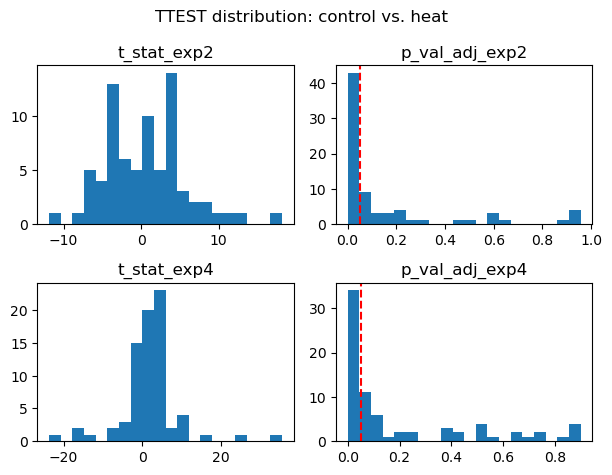

In [8]:
fig, axs = plot(2, 2, "TTEST distribution: control vs. heat", df_sld_stat, [["t_stat_exp2", "p_val_adj_exp2"], ["t_stat_exp4", "p_val_adj_exp4"]], 20)
axs[0, 1].axvline(0.05, linestyle="--", color="red")
axs[1, 1].axvline(0.05, linestyle="--", color="red")

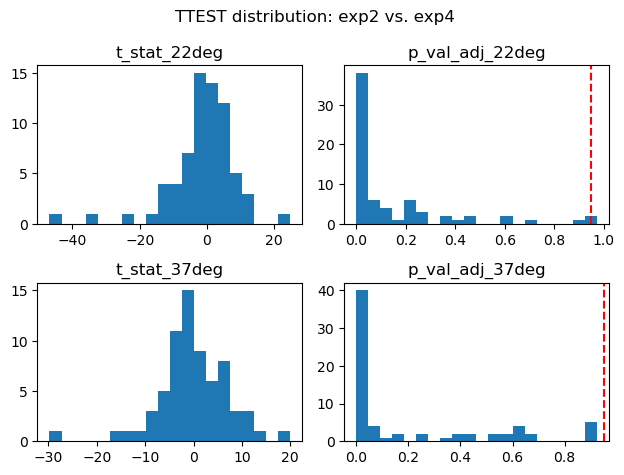

In [9]:
fig, axs = plot(2, 2, "TTEST distribution: exp2 vs. exp4", df_sld_stat, [["t_stat_22deg", "p_val_adj_22deg"], ["t_stat_37deg", "p_val_adj_37deg"]], 20)
axs[0, 1].axvline(0.95, linestyle="--", color="red")
axs[1, 1].axvline(0.95, linestyle="--", color="red")

### Fold change

In [10]:
## fold change between 22deg and 37deg
df_sld_stat["log2_fc_exp2"] = df_sld_stat["mean_sum_exp2_37deg"] - df_sld_stat["mean_sum_exp2_22deg"] # -> FC = 1 means under heat stress compound is twice as high 
df_sld_stat["log2_fc_exp4"] = df_sld_stat["mean_sum_exp4_37deg"] - df_sld_stat["mean_sum_exp4_22deg"]
df_sld_stat

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.448803,0.524755,NaN,NaN,NaN,NaN,NaN,NaN,0.177009,1.342539
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.337383,0.427352,-0.870844,0.418621,0.465885,-2.806790,0.043798,0.071954,-2.160908,0.918180
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,0.000058,0.000632,1.587388,0.185403,0.234441,0.208346,0.841975,0.893789,1.126581,1.211926
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.001791,0.009074,-4.545882,0.003946,0.011345,-5.563614,0.001549,0.005939,-0.963636,-0.683510
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,0.000103,0.000975,-1.743708,0.163177,0.216523,-7.802533,0.000932,0.004730,-0.804803,-0.388788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,0.002187,0.009776,-13.780549,0.000013,0.000178,-12.759618,0.000117,0.000896,0.133789,-0.317630
168,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,0.032655,0.063634,-7.282114,0.002481,0.007459,-1.917969,0.111243,0.166864,0.308988,-0.165103
170,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.424354,0.520175,-10.012694,0.001742,0.006010,-2.472863,0.054605,0.085631,0.329323,-0.033241
172,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.017217,0.040236,-4.548343,0.005860,0.014442,3.217403,0.020625,0.038463,0.339597,-0.252840


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


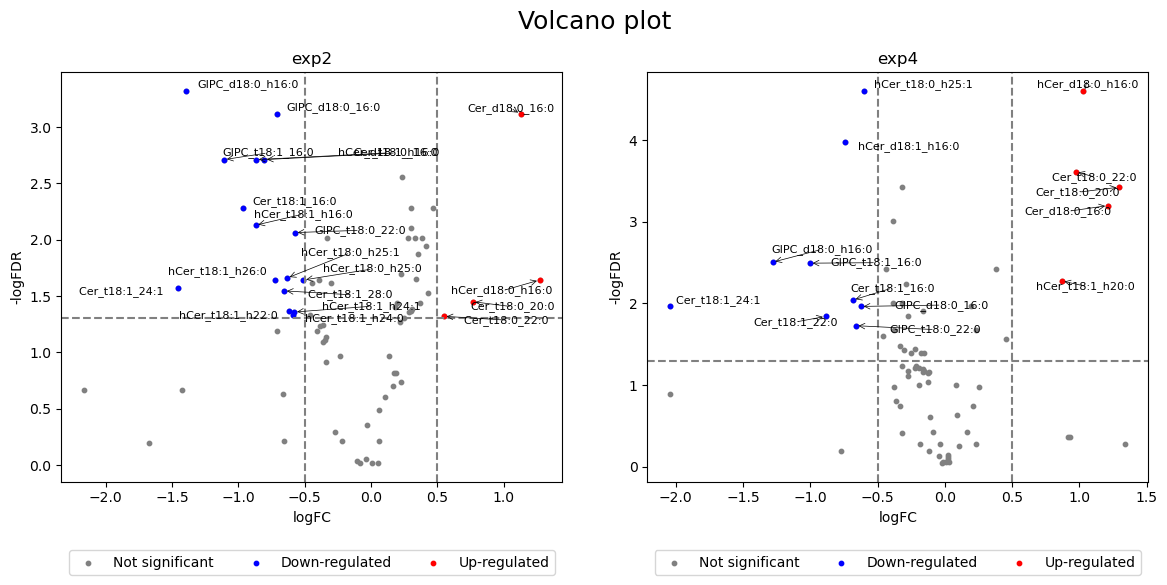

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))

for i, exp in enumerate(["exp2", "exp4"]):
    df_volcano = df_sld_stat[["compound", f"log2_fc_{exp}", f"p_val_adj_{exp}"]]
    df_volcano.columns = ["compounds", "log2_fc", "p_val_adj"]

    plot_volcano(df_volcano, compounds_col="compounds", fcr_col="p_val_adj", fc_col="log2_fc", significance=0.05, fc_level=0.5, title=exp, ax=axs[i])

plt.suptitle("Volcano plot", fontsize=18)
plt.tight_layout()
plt.show()

### Skewness

In [12]:
df_sld_stat["skew_exp2_22deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
df_sld_stat["skew_exp2_37deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
df_sld_stat["skew_exp4_22deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp4_22deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
df_sld_stat["skew_exp4_37deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp4_37deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
df_sld_stat

C:\Users\janni\AppData\Local\Temp\ipykernel_5332\4215796913.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_sld_stat["skew_exp2_22deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
C:\Users\janni\AppData\Local\Temp\ipykernel_5332\4215796913.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_sld_stat["skew_exp2_37deg"] = [skew(df_sld_stat.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df_sld_stat))]
C:\Users\janni\AppData\Local\Temp\ipykernel_5332\4215796913.py:3: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_sld_stat["

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4,skew_exp2_22deg,skew_exp2_37deg,skew_exp4_22deg,skew_exp4_37deg
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.177009,1.342539,NaN,NaN,-1.148662,-0.052682
2,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.465885,-2.806790,0.043798,0.071954,-2.160908,0.918180,0.801861,1.154700,0.141094,-0.161438
4,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955688,3.749633,3.815411,3.620979,13.400314,...,0.234441,0.208346,0.841975,0.893789,1.126581,1.211926,0.998984,-0.493437,-0.460003,0.215702
6,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.011345,-5.563614,0.001549,0.005939,-0.963636,-0.683510,-1.051637,0.271000,-0.867240,0.100740
8,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343889,0.868836,1.064285,1.029625,0.897859,25.668386,...,0.216523,-7.802533,0.000932,0.004730,-0.804803,-0.388788,-0.285720,0.258778,0.444326,0.864513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,0.000178,-12.759618,0.000117,0.000896,0.133789,-0.317630,0.223343,-0.257210,-1.015173,-0.143728
168,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,0.007459,-1.917969,0.111243,0.166864,0.308988,-0.165103,0.402767,0.400414,0.123763,-0.037086
170,GIPC_t18:0_h26:1,1.465321,1.791600,1.733307,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.006010,-2.472863,0.054605,0.085631,0.329323,-0.033241,-1.078132,0.133269,0.097222,0.398783
172,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.014442,3.217403,0.020625,0.038463,0.339597,-0.252840,-0.919226,-0.465748,0.968028,0.022852


(<Figure size 640x480 with 4 Axes>,
 array([[<Axes: title={'center': 'skew_exp2_22deg'}>,
         <Axes: title={'center': 'skew_exp2_37deg'}>],
        [<Axes: title={'center': 'skew_exp4_22deg'}>,
         <Axes: title={'center': 'skew_exp4_37deg'}>]], dtype=object))

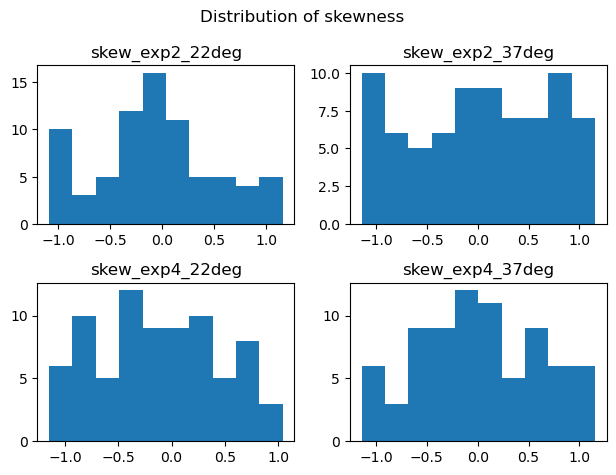

In [13]:
plot(2, 2, "Distribution of skewness", df_sld_stat, [["skew_exp2_22deg", "skew_exp2_37deg"], ["skew_exp4_22deg", "skew_exp4_37deg"]], 10)

## Save results

In [ ]:
#df_sld_stat.to_csv(f"../data/preprocessed/sld_24h.csv", index=False)

## PCA

In [4]:
sld_df = pd.read_csv("../data/preprocessed/sld_24h.csv")
sld_df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4,skew_exp2_22deg,skew_exp2_37deg,skew_exp4_22deg,skew_exp4_37deg
0,Cer_d18:0_16:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.177009,1.342539,NaN,NaN,-1.148662,-0.052682
1,Cer_d18:1_16:0,0.011683,0.016081,0.125435,0.027237,0.000000,0.000000,0.000000,0.104916,2.161807,...,0.465884,-2.806790,0.043798,0.071954,-2.160908,0.918180,0.801861,1.154700,0.141094,-0.161438
2,Cer_d18:0_16:0,1.360708,1.344452,1.735799,1.341510,2.955687,3.749633,3.815411,3.620979,13.400314,...,0.234441,0.208346,0.841975,0.893789,1.126581,1.211926,0.998984,-0.493437,-0.460003,0.215702
3,Cer_t18:1_16:0,0.029186,0.027262,0.028427,0.020617,0.007486,0.011031,0.008913,0.006612,0.266304,...,0.011345,-5.563614,0.001549,0.005939,-0.963636,-0.683510,-1.051637,0.271000,-0.867240,0.100740
4,Cer_t18:0_16:0,3.199261,2.601099,3.006016,2.343888,0.868836,1.064285,1.029625,0.897859,25.668386,...,0.216523,-7.802533,0.000932,0.004730,-0.804803,-0.388788,-0.285720,0.258778,0.444326,0.864513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,GIPC_t18:0_h25:0,0.568305,0.736147,0.604690,0.664514,0.623234,0.665781,0.647886,0.588056,10.947737,...,0.000178,-12.759618,0.000117,0.000896,0.133789,-0.317630,0.223343,-0.257210,-1.015173,-0.143728
80,GIPC_t18:1_h26:1,0.061285,0.084905,0.062870,0.073508,0.080495,0.078044,0.074748,0.086821,0.986198,...,0.007459,-1.917969,0.111243,0.166864,0.308988,-0.165103,0.402767,0.400414,0.123763,-0.037086
81,GIPC_t18:0_h26:1,1.465321,1.791600,1.733308,1.753825,1.858596,1.915429,2.070923,1.990747,19.625135,...,0.006010,-2.472863,0.054605,0.085631,0.329323,-0.033241,-1.078132,0.133269,0.097222,0.398783
82,GIPC_t18:1_h26:0,0.559695,0.685156,0.725629,0.744883,0.706158,0.779379,0.864867,0.834427,8.238372,...,0.014442,3.217403,0.020625,0.038463,0.339597,-0.252840,-0.919226,-0.465748,0.968028,0.022852


In [ ]:
df_pca = sld_df.filter(regex=r"^sum_exp\d+_\d+deg_\d+").T
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca)

pca = PCA(n_components=2)
scores = pca.fit_transform(df_pca_scaled)

array([[-0.78123415, -0.4762461 , -0.9493807 , ..., -2.30585792,
        -2.14791044, -1.26539435],
       [-0.78123415, -0.31382122, -0.98137714, ..., -1.26498288,
        -1.01393127, -1.32964294],
       [-0.78123415,  0.73046715, -0.59456184, ..., -1.43624579,
        -0.69215827, -1.07338222],
       ...,
       [ 1.08150539,  0.57629004,  1.22044806, ...,  0.501273  ,
        -1.25831526,  0.91695597],
       [ 1.03669607,  1.11967781,  0.8217388 , ...,  1.14123208,
         0.15778646,  1.21624529],
       [ 0.73556465,  1.46215242,  1.06307374, ...,  0.71433295,
        -0.1205628 ,  0.89406322]], shape=(16, 84))

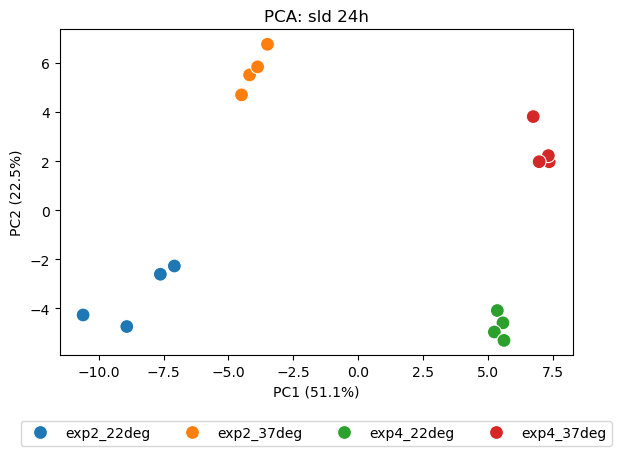

In [13]:
# PCA scores in DataFrame
df_pca_plot = pd.DataFrame(scores, columns=['PC1', 'PC2'])

# add groups
groups = ["exp2_22deg"]*4 + ["exp2_37deg"]*4 + ["exp4_22deg"]*4 + ["exp4_37deg"]*4
df_pca_plot['group'] = groups

# Plot
sns.scatterplot(data=df_pca_plot, x="PC1", y="PC2", hue="group", s=100)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA: sld 24h")
plt.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.3))
plt.tight_layout()

## Batch correction

In [22]:
batch_df = preprocessing(pd.read_csv("../data/formated/sld_24h.csv"), replace_zero="half_min_loc", relative_values=False)
results_df = batch_correction(batch_df)
results_df["category"] = categorize_compounds(results_df)
print(f"{len(results_df[results_df["category"] == "both"])} compounds show both significant temperature and batch effect,")
print(f"{len(results_df[results_df["category"] == "condition"])} compounds show significant temperature effect,")
print(f"{len(results_df[results_df["category"] == "batch"])} compounds show significant batch effect,")
print(f"{len(results_df[results_df["category"] == "neutral"])} compounds show no significant effect.")
results_df

c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[i, sum_cols] = df.loc[i, sum_cols].replace(0, half_min)
c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[i, sum_cols] = df.loc[i, sum_cols].replace(0, half_min)
c:\Users\janni\Desktop\sphingo_modelling\code\functions.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavio

20 compounds show both significant temperature and batch effect,
0 compounds show significant temperature effect,
60 compounds show significant batch effect,
4 compounds show no significant effect.


,compound,EffectSize_condition,p_val_condition,p_val_batch,R2,p_val_adj_condition,category
0,Cer_d18:0_16:1,0.063636,7.965938e-01,1.182852e-04,0.693252,8.804458e-01,batch
1,Cer_d18:1_16:0,-0.017913,9.782931e-01,9.095291e-05,0.704608,9.900798e-01,batch
2,Cer_d18:0_16:0,1.031742,3.027573e-10,6.347591e-14,0.990650,8.477206e-09,both
3,Cer_t18:1_16:0,-0.961085,3.913391e-07,9.668756e-13,0.984013,4.109060e-06,both
4,Cer_t18:0_16:0,-0.734307,8.843774e-07,4.092905e-13,0.985619,8.254189e-06,both
...,...,...,...,...,...,...,...
79,GIPC_t18:0_h25:0,-0.229432,2.898340e-03,1.672171e-15,0.993309,7.608141e-03,batch
80,GIPC_t18:1_h26:1,-0.065569,3.820856e-01,5.496282e-14,0.988481,4.862908e-01,batch
81,GIPC_t18:0_h26:1,0.010529,8.356133e-01,5.912514e-16,0.994258,8.998912e-01,batch
82,GIPC_t18:1_h26:0,-0.094133,3.043859e-01,3.494921e-12,0.978221,4.191544e-01,batch


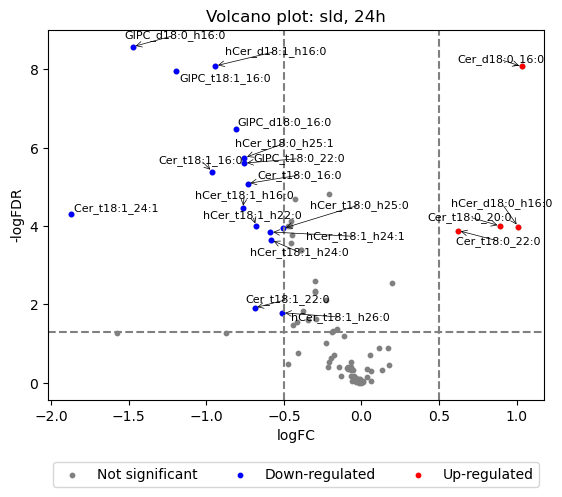

In [24]:
fig, ax = plot_volcano(results_df, compounds_col="compound", fcr_col="p_val_adj_condition", fc_col="EffectSize_condition", title="Volcano plot: sld, 24h", significance=0.05, fc_level=0.5)

# Network

In [22]:
wt_df = results_df.copy()
wt_df["significant"] = wt_df["p_val_adj_condition"] < 0.05
wt_df["class"] = wt_df["compound"].apply(extract_class)
wt_df["chain_length"] = wt_df["compound"].apply(extract_chain_length)
wt_df["chain_category"] = wt_df["chain_length"].apply(categorize_chain_length)
wt_df["sphingo_hydroxylation"] = wt_df["compound"].apply(extract_sphingo_hydroxylation)
wt_df["fatty_hydroxylation"] = wt_df["compound"].apply(extract_fatty_hydroxylation)
wt_df["double_bounds"] = wt_df["compound"].apply(extract_double_bounds)
wt_df

,compound,EffectSize_condition,p_val_condition,p_val_batch,R2,p_val_adj_condition,category,significant,class,chain_length,chain_category,sphingo_hydroxylation,fatty_hydroxylation,double_bounds
0,Cer_d18:0_16:1,0.826202,1.803236e-07,4.983508e-12,0.980425,2.957307e-06,both,True,Ceramide,16,short,2,False,1
1,Cer_d18:1_16:0,0.850759,8.482787e-02,9.620912e-05,0.724108,1.264706e-01,batch,False,Ceramide,16,short,2,False,0
2,Cer_d18:0_16:0,1.420793,1.604046e-10,7.278261e-12,0.984712,6.576590e-09,both,True,Ceramide,16,short,2,False,0
3,Cer_t18:1_16:0,-0.606641,3.311330e-03,2.164133e-09,0.944687,9.697466e-03,both,True,Ceramide,16,short,3,False,0
4,Cer_t18:0_16:0,0.000298,9.979675e-01,1.102144e-11,0.973969,9.979675e-01,batch,False,Ceramide,16,short,3,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,GIPC_t18:0_h25:0,-0.009834,8.740469e-01,9.433588e-15,0.991209,9.263576e-01,batch,False,GIPC,25,very_long,3,True,0
78,GIPC_t18:1_h26:1,-0.003185,9.514306e-01,6.490143e-17,0.995912,9.631766e-01,batch,False,GIPC,26,very_long,3,True,1
79,GIPC_t18:1_h26:0,-0.063201,2.533929e-01,6.615002e-16,0.994161,3.196649e-01,batch,False,GIPC,26,very_long,3,True,0
80,GIPC_t18:1_h28:1,-0.022667,7.909694e-01,6.192561e-15,0.991760,8.764796e-01,batch,False,GIPC,28,very_long,3,True,1


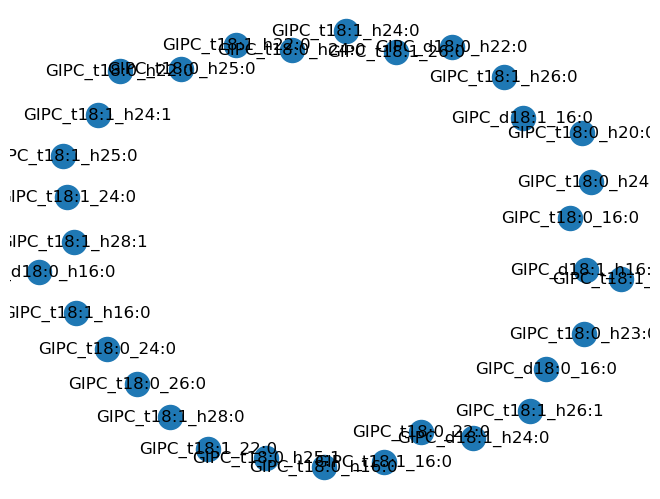

In [43]:
G = nx.Graph()
G.add_nodes_from(wt_df[wt_df["class"] == "GIPC"]["compound"])
nx.draw(G, with_labels=True)

# To Do
- mutant: no dbs on sphingo base, more heat sensitive -> compounds (heatmarkers) missing in mutant?
 -> compound profile in mutant (heat markers)

# Notes

# Questions
- Sind exp2 und exp4 exakt gleich durchgeführt?
- Compound classes for enrichment?
